In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
from eda_package import *

In [4]:
path = "/Users/beza/code/bezawitzyb/noshowshield/raw_data/hotel_bookings.csv"
df= load_raw_data(path)

In [5]:
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df= clean_data(df)
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,0.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,0.0,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,0.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,0.0,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,0.0,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,0.0,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,0.0,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [7]:
df= engineer_features(df)
df


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reservation_status_date,total_stay_nights,has_children,is_last_minute,season,total_previous_bookings,prev_cancel_ratio,total_revenue,segment_cancel_rate,has_deposit
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,2015-07-01,0,0,0,Summer,0,-1.0,0.00,0.147154,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,2015-07-01,0,0,0,Summer,0,-1.0,0.00,0.147154,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,2015-07-02,1,0,0,Summer,0,-1.0,75.00,0.147154,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,2015-07-02,1,0,0,Summer,0,-1.0,75.00,0.121083,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,2015-07-03,2,0,0,Summer,0,-1.0,196.00,0.353462,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,2017-09-06,7,0,0,Summer,0,-1.0,672.98,0.148535,0
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,2017-09-07,7,0,0,Summer,0,-1.0,1578.01,0.353462,0
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,2017-09-07,7,0,0,Summer,0,-1.0,1103.97,0.353462,0
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,2017-09-07,7,0,0,Summer,0,-1.0,730.80,0.353462,0


In [8]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_stay_nights',
       'has_children', 'is_last_minute', 'season', 'total_previous_bookings',
       'prev_cancel_ratio', 'total_revenue', 'segment_cancel_rate',
       'has_deposit'],
      dtype='object')

In [9]:
cols_to_drop=["stays_in_weekend_nights", "stays_in_week_nights", "total_previous_bookings", "total_revenue", "is_last_minute"]
df= df.drop(columns=cols_to_drop)

In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'is_canceled' in numerical_cols:
    numerical_cols.remove('is_canceled')

correlations = df[numerical_cols].corrwith(df['is_canceled']).sort_values(key=abs, ascending=False)

print("Correlation with is_canceled (sorted by |r|):")
print("=" * 55)
for feat, corr in correlations.items():
    bar_len = int(abs(corr) * 50)
    bar = '#' * bar_len
    direction = '+' if corr > 0 else '-'
    print(f"  {feat:<40} {direction}{abs(corr):.3f}  {bar}")

Correlation with is_canceled (sorted by |r|):
  segment_cancel_rate                      +0.221  ###########
  lead_time                                +0.185  #########
  required_car_parking_spaces              -0.184  #########
  has_deposit                              +0.156  #######
  adr                                      +0.128  ######
  total_of_special_requests                -0.121  ######
  booking_changes                          -0.094  ####
  is_repeated_guest                        -0.090  ####
  arrival_date_year                        +0.088  ####
  total_stay_nights                        +0.084  ####
  adults                                   +0.082  ####
  company                                  -0.075  ###
  children                                 +0.067  ###
  prev_cancel_ratio                        +0.059  ##
  previous_bookings_not_canceled           -0.052  ##
  has_children                             +0.052  ##
  previous_cancellations                  

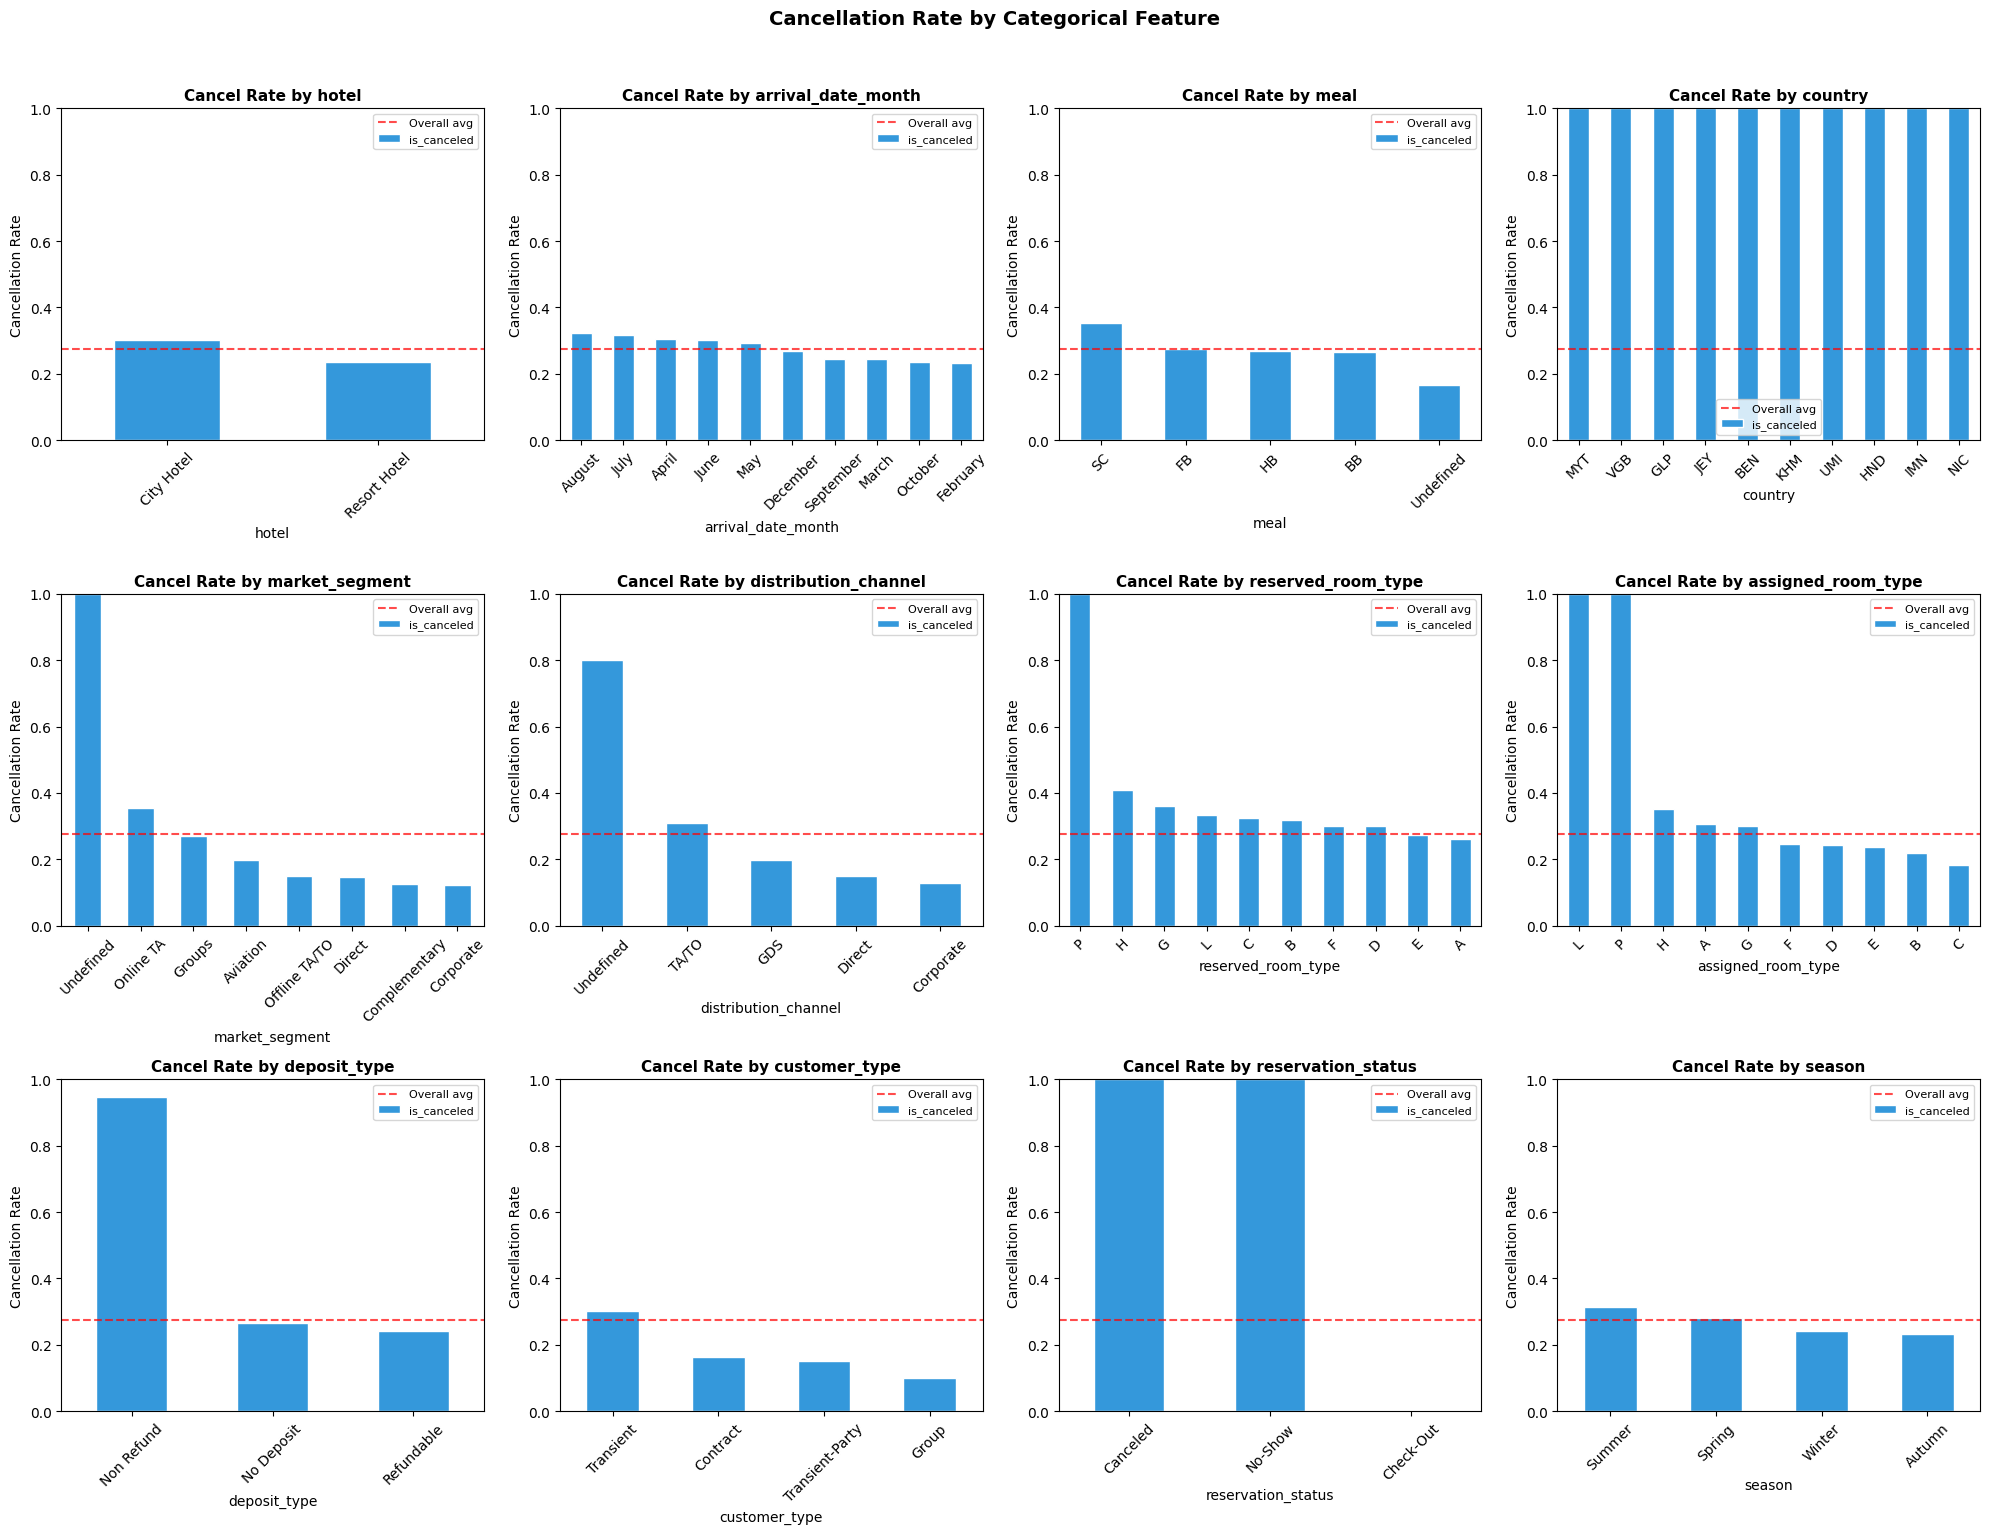

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
import math

n_cols = 4
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        cancel_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
        if len(cancel_rate) > 10:
            cancel_rate = cancel_rate.head(10)

        cancel_rate.plot(kind='bar', ax=axes[i], color='#3498db', edgecolor='white')
        axes[i].set_title(f'Cancel Rate by {col}', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Cancellation Rate')
        axes[i].set_ylim(0, 1)
        axes[i].axhline(y=df['is_canceled'].mean(), color='red', linestyle='--',
                         alpha=0.7, label='Overall avg')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(fontsize=8)

plt.suptitle('Cancellation Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
from scipy.stats import pointbiserialr, chi2_contingency

print("Statistical Tests - Feature Importance")
print("=" * 70)

# Point-biserial for numerical features
print("\nNumerical Features (Point-Biserial Correlation):")
print("-" * 60)
results_num = []
for col in numerical_cols:
    if df[col].nunique() > 1:
        corr, pval = pointbiserialr(df['is_canceled'], df[col])
        results_num.append((col, abs(corr), pval))

results_num.sort(key=lambda x: x[1], reverse=True)
for col, corr, pval in results_num[:15]:
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {col:<40} |r| = {corr:.4f}  p = {pval:.2e}  {sig}")

Statistical Tests - Feature Importance

Numerical Features (Point-Biserial Correlation):
------------------------------------------------------------
  segment_cancel_rate                      |r| = 0.2210  p = 0.00e+00  ***
  lead_time                                |r| = 0.1848  p = 0.00e+00  ***
  required_car_parking_spaces              |r| = 0.1842  p = 0.00e+00  ***
  has_deposit                              |r| = 0.1565  p = 0.00e+00  ***
  adr                                      |r| = 0.1280  p = 7.85e-316  ***
  total_of_special_requests                |r| = 0.1205  p = 3.67e-280  ***
  booking_changes                          |r| = 0.0936  p = 2.04e-169  ***
  is_repeated_guest                        |r| = 0.0896  p = 2.31e-155  ***
  arrival_date_year                        |r| = 0.0880  p = 7.11e-150  ***
  total_stay_nights                        |r| = 0.0841  p = 6.29e-137  ***
  adults                                   |r| = 0.0818  p = 1.14e-129  ***
  company         

In [13]:
# Cramer's V for categorical features
def cramers_v(x, y):
    """Compute Cramer's V - strength of association between two categorical variables."""
    contingency = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency)[0]
    n = len(x)
    min_dim = min(contingency.shape) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

print("Categorical Features (Cramer's V with is_canceled):")
print("-" * 60)

results_cat = []
for col in categorical_cols:
    if col in df.columns:
        v = cramers_v(df[col], df['is_canceled'])
        results_cat.append((col, v))

results_cat.sort(key=lambda x: x[1], reverse=True)
for col, v in results_cat:
    strength = 'Strong' if v > 0.25 else 'Moderate' if v > 0.10 else 'Weak'
    print(f"  {col:<35} V = {v:.4f}  ({strength})")

Categorical Features (Cramer's V with is_canceled):
------------------------------------------------------------
  reservation_status                  V = 1.0000  (Strong)
  market_segment                      V = 0.2210  (Moderate)
  country                             V = 0.1971  (Moderate)
  deposit_type                        V = 0.1651  (Moderate)
  distribution_channel                V = 0.1525  (Moderate)
  customer_type                       V = 0.1271  (Moderate)
  assigned_room_type                  V = 0.0947  (Weak)
  arrival_date_month                  V = 0.0856  (Weak)
  season                              V = 0.0759  (Weak)
  hotel                               V = 0.0716  (Weak)
  meal                                V = 0.0633  (Weak)
  reserved_room_type                  V = 0.0583  (Weak)


/Users/beza/.pyenv/versions/3.10.6/envs/noshowshield/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


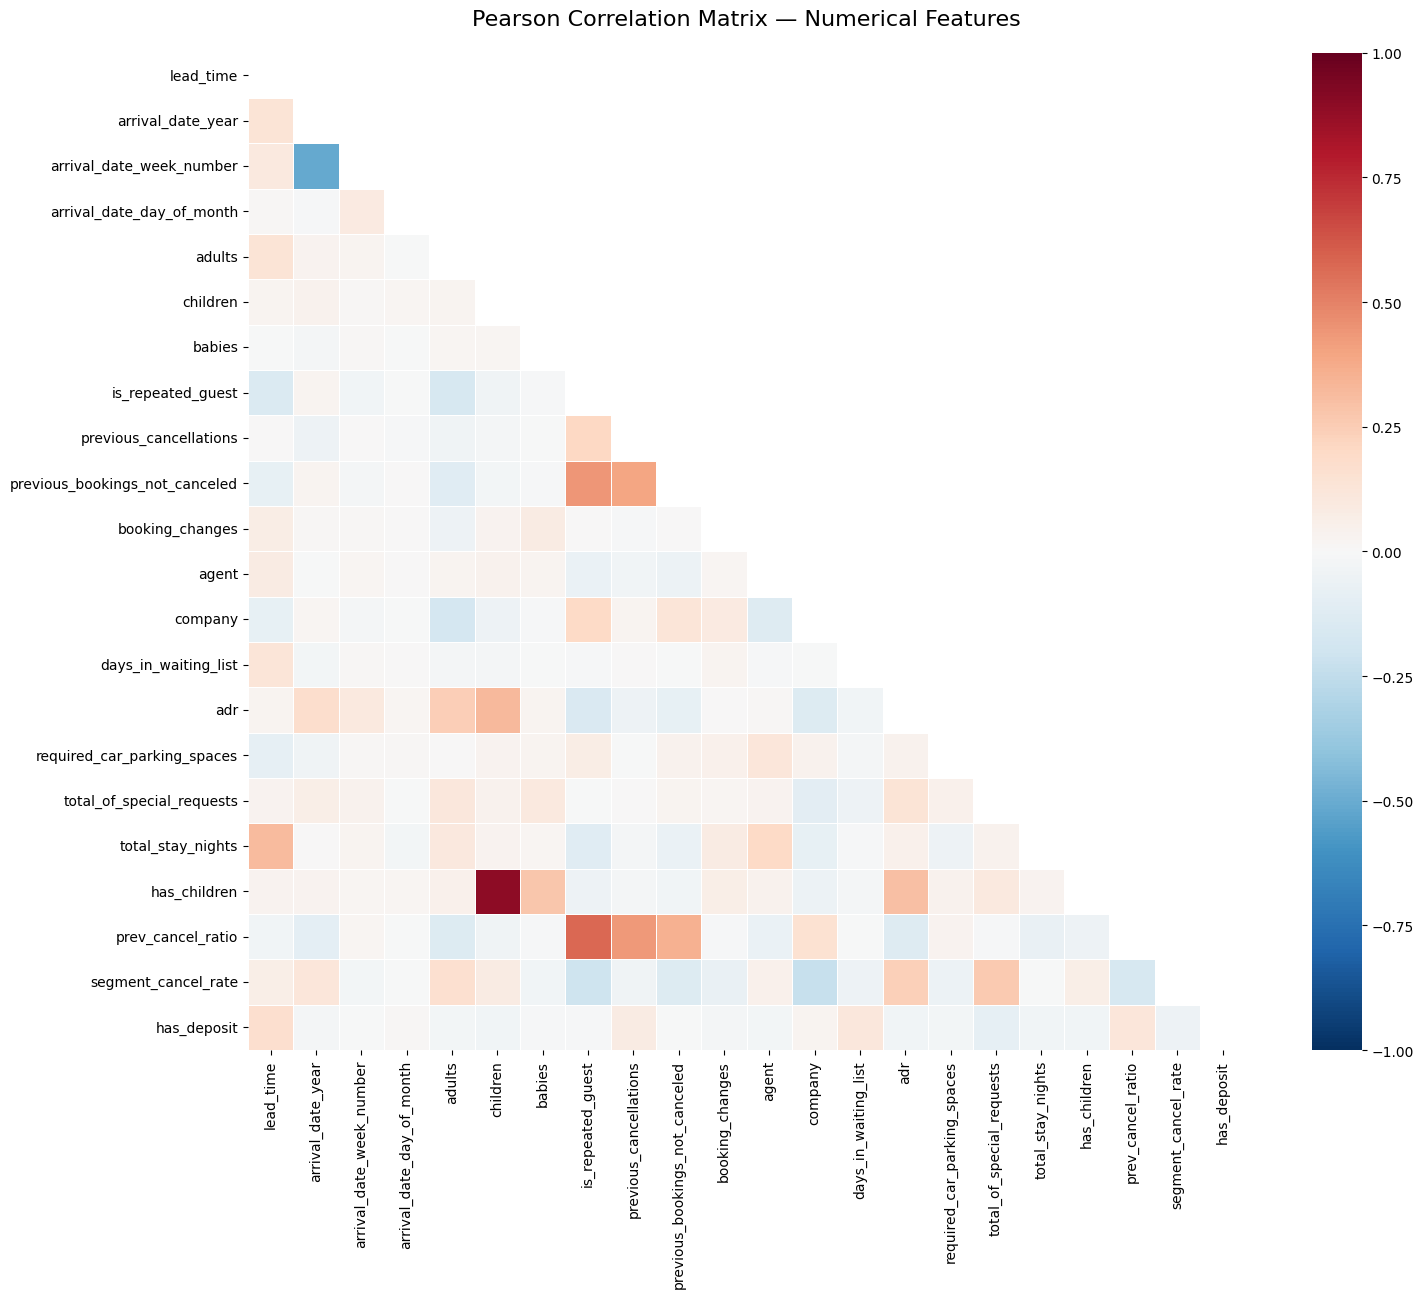

In [14]:
corr_matrix = df[numerical_cols].corr()

# Plot
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix — Numerical Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [15]:
train , test = temporal_split(df,)

In [16]:
train.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'total_stay_nights',
       'has_children', 'season', 'prev_cancel_ratio', 'segment_cancel_rate',
       'has_deposit', 'arrival_date'],
      dtype='object')

In [17]:
X_train, y_train= split_X_y(train)
X_test, y_test= split_X_y(test)

In [18]:
X_train_processed, X_test_processed =preprocess_pipeline(X_train, X_test, ORDINAL_FEATURES_MAP)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score

# Initialize model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train_processed, y_train)

# Predictions
y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]  # Probabilities for ROC-AUC

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# Print results
print(f"Accuracy:  {accuracy:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Accuracy:  0.7535
ROC-AUC:   0.8122
Precision: 0.6087
Recall:    0.6373


/Users/beza/.pyenv/versions/3.10.6/envs/noshowshield/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
# Get coefficients
coefficients = model.coef_[0]

# Create DataFrame
feature_importance = pd.DataFrame({
    "feature": X_train_processed.columns,
    "coefficient": coefficients,
    "abs_importance": np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="abs_importance", ascending=False)

print(feature_importance.head(20))

                                 feature  coefficient  abs_importance
14      num__required_car_parking_spaces    -6.080860        6.080860
29               cat_onehot__country_ARE     2.193598        2.193598
215     cat_onehot__assigned_room_type_I    -2.166791        2.166791
19                bin__is_repeated_guest    -2.013615        2.013615
220  cat_onehot__deposit_type_Non Refund     1.826691        1.826691
207     cat_onehot__assigned_room_type_A     1.813326        1.813326
17                num__prev_cancel_ratio     1.759760        1.759760
86               cat_onehot__country_HKG     1.701361        1.701361
197     cat_onehot__reserved_room_type_A    -1.682427        1.682427
153              cat_onehot__country_SAU     1.604592        1.604592
221  cat_onehot__deposit_type_Refundable    -1.577579        1.577579
132              cat_onehot__country_NGA     1.565232        1.565232
213     cat_onehot__assigned_room_type_G    -1.509139        1.509139
25               cat

In [21]:
least_important = feature_importance.sort_values(by="abs_importance", ascending=True)

print(least_important.head(30))

                                  feature  coefficient  abs_importance
11                           num__company    -0.000875        0.000875
129               cat_onehot__country_MWI    -0.001286        0.001286
159               cat_onehot__country_STP    -0.002565        0.002565
61                cat_onehot__country_CYM    -0.002756        0.002756
12              num__days_in_waiting_list    -0.004143        0.004143
31                cat_onehot__country_ARM    -0.004777        0.004777
180               cat_onehot__country_VNM    -0.004957        0.004957
183               cat_onehot__country_ZWE    -0.005322        0.005322
36                cat_onehot__country_BDI    -0.007753        0.007753
48                cat_onehot__country_BWA    -0.010167        0.010167
57                cat_onehot__country_COM    -0.010683        0.010683
49                cat_onehot__country_CAF    -0.010786        0.010786
76                cat_onehot__country_GAB     0.011529        0.011529
44    

In [22]:
threshold = 0.01

features_to_drop = feature_importance[
    feature_importance["abs_importance"] < threshold
]["feature"].tolist()

In [23]:
features_to_drop

['cat_onehot__country_BDI',
 'cat_onehot__country_ZWE',
 'cat_onehot__country_VNM',
 'cat_onehot__country_ARM',
 'num__days_in_waiting_list',
 'cat_onehot__country_CYM',
 'cat_onehot__country_STP',
 'cat_onehot__country_MWI',
 'num__company']